In [200]:
import glob
import re
import os

first_layer_names = glob.glob('[0-9][0-9][0-9]',root_dir='./mached_catalog')
print(len(first_layer_names))
count = 0
print(os.getcwd())
for name in first_layer_names:
    second_layer_names = glob.glob('[0-9][0-9][0-9][0-9]*',                                   root_dir='./mached_catalog/'+name)
        
    for long_name in second_layer_names:
        if True == os.path.isfile('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv'):
            count += 1
print(count)

359
/home/kangzihan/project_unTimely_light_curve
17520


In [171]:
import os
import pandas as pd
print(os.getcwd())
table = pd.read_csv('./mached_catalog/116/1165p287/1165p287_w1_mached.csv')

/home/kangzihan/project_unTimely_light_curve


In [106]:
import numpy as np

def calculate_magnitude(flux):
    if flux <= 0:
        return np.nan
    return 22.5 - 2.5 * np.log10(flux)

def calculate_error(flux,dflux):
    mag_upper = calculate_magnitude(flux - dflux)
    mag_lower = calculate_magnitude(flux + dflux)
    dmag = (mag_upper - mag_lower) / 2
    return dmag

cal_mag_ufunc  = np.frompyfunc(calculate_magnitude,1,1)
cal_error_ufunc  = np.frompyfunc(calculate_error,2,1)



In [107]:

def make_single_light_curve(table, index):
    line = table.iloc[index]
    line_len = len(line)
    ra = line[0]
    dec = line[1]
    flux_unfiltered = line[3:line_len:3]
    flux = np.array(flux_unfiltered[flux_unfiltered.notnull()])
    dflux_unfiltered = line[4:line_len:3]
    dflux = np.array(dflux_unfiltered[dflux_unfiltered.notnull()])
    mjdmean_unfiltered = line[5:line_len:3]
    mjdmean = np.array(mjdmean_unfiltered[mjdmean_unfiltered.notnull()])
    assert len(flux)==len(dflux) and len(dflux)==len(mjdmean), 'light curve uncomplete!'
    mag = cal_mag_ufunc(flux)
    error = cal_error_ufunc(flux,dflux)
    return ra,dec,mag, error, mjdmean




In [ ]:
[2609.0, 3470.0, 4297.0, 4355.0, 5495.0, 6734.0, 6901.0, 7040.0, 8165.0, 8529.0, 8669.0, 9614.0, 10703.0, 12966.0, 13094.0, 15923.0, 16396.0, 16424.0, 17005.0, 17276.0, 18247.0, 19667.0, 20653.0, 20812.0, 21101.0, 21238.0, 21279.0, 22203.0, 23388.0, 24230.0, 24458.0, 26393.0, 26573.0, 28299.0, 28781.0, 28784.0, 29084.0, 30295.0, 30847.0, 31115.0, 32417.0]


117.2135301 , 29.4960373


<ErrorbarContainer object of 3 artists>

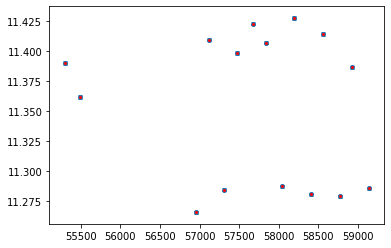

In [212]:
import matplotlib.pyplot as plt
ra,dec,mag,error,mjdmean = make_single_light_curve(table,32417)
print(ra,',',dec)
plt.errorbar(mjdmean,mag,error,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)

In [143]:
count = 0
light_count = 0
for i in range(0,len(table)):
    flux,dflux,mjdmean = make_single_light_curve(table,i)
    if len(flux) >= 10:
        count += 1
    mean_flux = np.mean(flux)
    if mean_flux > 500:
        light_count += 1
print(count)
print(light_count)

23374
4288
